In [1]:
# fix seed
import numpy as np
np.random.seed(1234)

In [2]:
import pandas as pd

def hpo_result_1(df, dataset, model, num_steps, regression, start_by_default=False):
    # Validate the input DataFrame and ensure it has the necessary columns
    if not isinstance(df, pd.DataFrame):
        raise ValueError("The to_plot argument must be a pandas DataFrame.")
    
    required_columns = {'mean_val_score', 'mean_test_score', 'data__keyword', 'model_name'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"The DataFrame must contain the following columns: {required_columns}")
    
    # Filter the DataFrame for the given dataset and model
    filtered_df = df[(df['data__keyword'] == dataset) & (df['model_name'] == model) & (df['data__regression'] == regression)]

    random_df = filtered_df[filtered_df['hp'] == 'random']

    default_df = filtered_df[filtered_df['hp'] == 'default']
    #default_df = default_df.sample(n=1, random_state=None)
    val_score_default = default_df['mean_val_score'].values[0]
    test_score_default = default_df['mean_test_score'].values[0]
    
    #assert len(random_df) >= num_steps, "not enough random steps"
    if len(random_df) >= num_steps:
        # If start_by_default is True or if there are enough rows, proceed to sample
        sampled_df = random_df.sample(n=min(num_steps, filtered_df.shape[0]), random_state=None)
        
        # Identify the row with the best 'mean_val_score'
        best_row = sampled_df.loc[sampled_df['mean_val_score'].idxmax()]
        
        # Extract the best 'mean_val_score' and its corresponding 'mean_test_score'
        best_mean_val_score = best_row['mean_val_score']
        corresponding_mean_test_score = best_row['mean_test_score']

        if start_by_default:
            if val_score_default > best_mean_val_score:
                best_mean_val_score = val_score_default
                corresponding_mean_test_score = test_score_default
        return pd.DataFrame({
            'best_mean_val_score': [best_mean_val_score],
            'corresponding_mean_test_score': [corresponding_mean_test_score]
            }), pd.DataFrame({
            'val_score_default': [val_score_default],
            'test_score_default': [test_score_default]
            })
    else:
        #print("WARNING: not enough random steps")
        #print("Only returning default values")
        assert ("david" in model) and not ("david_not_simple" in model)
        return pd.DataFrame(), pd.DataFrame({
            'val_score_default': [val_score_default],
            'test_score_default': [test_score_default]
            })
def hpo_result(df, dataset, model, num_steps, regression, start_by_default=False, n_repeats=5):
    res_df = pd.DataFrame()
    default_df = pd.DataFrame()
    for i in range(n_repeats):
        result, default = hpo_result_1(df, dataset, model, num_steps, regression, start_by_default)
        res_df = pd.concat([res_df, result])
        default_df = pd.concat([default_df, default])
    # average the results
    #print(res_df)
    #print(default_df)
    res_df = res_df.mean()
    default_df = default_df.mean()
    return res_df, default_df



def best_score_td(df, dataset, regression):
    models = ["david_not_simple", "david_xgboost", "david_catboost", "david_lightgbm"]
    if regression:
        models = [model + "_regressor" for model in models]
    # check that the models are in df
    for model in models:
        assert df[(df["model_name"] == model) & (df["data__keyword"] == dataset) & (df["data__regression"] == regression) & (df["hp"] == "default")].shape[0] > 0, \
            f"Model {model} not found in the DataFrame for dataset {dataset} and regression {regression}"

    filtered_df = df[df["model_name"].isin(models)]
    #print(filtered_df.model_name.unique())
    filtered_df = filtered_df[filtered_df["data__keyword"] == dataset]
    filtered_df = filtered_df[filtered_df["data__regression"] == regression]
    filtered_df = filtered_df[filtered_df["hp"] == "default"]
    #print(len(filtered_df))
    # if a model appears multiple times, take the first one
    filtered_df = filtered_df.drop_duplicates(subset=["model_name"])
    #print(filtered_df.shape)
    # find the best val score
    best_row = filtered_df.loc[filtered_df['mean_val_score'].idxmax()]
    best_mean_val_score = best_row['mean_val_score']
    corresponding_mean_test_score = best_row['mean_test_score']
    return pd.DataFrame({
            'best_mean_val_score': [best_mean_val_score],
            'corresponding_mean_test_score': [corresponding_mean_test_score]
            })


def hpo_result_1_multiple_models(df, dataset, models, num_steps, regression):
    # Validate the input DataFrame and ensure it has the necessary columns
    if not isinstance(df, pd.DataFrame):
        raise ValueError("The to_plot argument must be a pandas DataFrame.")
    
    required_columns = {'mean_val_score', 'mean_test_score', 'data__keyword', 'model_name'}
    if not required_columns.issubset(df.columns):
        raise ValueError(f"The DataFrame must contain the following columns: {required_columns}")
    
    # Filter the DataFrame for the given dataset and model
    best_mean_val_score_all_models = 0
    corresponding_mean_test_score_all_models = 0
    for model in models:
        filtered_df = df[(df['data__keyword'] == dataset) & (df['model_name'] == model) & (df['data__regression'] == regression)]

        random_df = filtered_df[filtered_df['hp'] == 'random']

        #default_df = default_df.sample(n=1, random_state=None)
        
        #assert len(random_df) >= num_steps, "not enough random steps"
        if len(random_df) >= num_steps:
            # If start_by_default is True or if there are enough rows, proceed to sample
            sampled_df = random_df.sample(n=min(num_steps, filtered_df.shape[0]), random_state=None)
            
            # Identify the row with the best 'mean_val_score'
            best_row = sampled_df.loc[sampled_df['mean_val_score'].idxmax()]
            
            # Extract the best 'mean_val_score' and its corresponding 'mean_test_score'
            best_mean_val_score = best_row['mean_val_score']
            corresponding_mean_test_score = best_row['mean_test_score']

            if best_mean_val_score > best_mean_val_score_all_models:
                best_mean_val_score_all_models = best_mean_val_score
                corresponding_mean_test_score_all_models = corresponding_mean_test_score
            #print(model, best_mean_val_score_all_models, corresponding_mean_test_score_all_models)
            
        else:
            raise ValueError(f"not enough random steps, found only {len(random_df)} steps / {num_steps} required for model {model}")
        
    return pd.DataFrame({
        'best_mean_val_score': [best_mean_val_score_all_models],
        'corresponding_mean_test_score': [corresponding_mean_test_score_all_models]
        })

def best_hpo_david(df, dataset, num_steps, regression, n_repeats=5):
    models = ["david_not_simple", "david_catboost", "david_lightgbm"]
    if regression:
        models = [model + "_regressor" for model in models]
    models.append("XGBoost")
    res_df = pd.DataFrame()
    for i in range(n_repeats):
        result = hpo_result_1_multiple_models(df, dataset, models, num_steps, regression)
        res_df = pd.concat([res_df, result])
    # average the results
    print(res_df)
    res_df = res_df.mean()
    return res_df



# Example usage:
# Assume 'df' is your DataFrame containing the HPO results
# results_df = hpo_result(df, 'your_dataset', 'your_model', 10, start_by_default=True)

In [3]:
# check if the results exist
import os
if not os.path.exists("results/grinsztajn_results.csv"):
    raise ValueError("The results file does not exist, see the instructions at https://github.com/dholzmueller/tab_bench_dev on how to download the results file")
df = pd.read_csv("results/grinsztajn_results.csv")

/var/folders/fy/__8z8cpn6gs04465sq9g1nq80000gn/T/ipykernel_91128/1209258915.py:5: DtypeWarning: Columns (33,34,60,62,67,78,82,86,92,94,98,99,100,101,102,108,110,119,121,128,129,130,131,132,133,135,140,143,146,147,149,150,151,155,156,163,168,172) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("results/grinsztajn_results.csv")


In [4]:
df_classif = df[df["data__regression"] == False]
df_reg = df[df["data__regression"] == True]

In [5]:
num_steps = 50
res_df_classif = pd.DataFrame()
for dataset in df_classif.data__keyword.unique():
    for model in df_classif.model_name.unique():
        if model != "HistGradientBoostingTree": # was only computed for categorical
                res_hpo, res_default = hpo_result(df_classif, dataset, model, num_steps, start_by_default=False,
                                                regression=False, n_repeats=20)
                if res_hpo.shape[0] > 0:
                    res = {
                        "dataset": dataset,
                        "model": model,
                        "hp": "random",
                        "num_steps": num_steps,
                        "best_mean_val_score": res_hpo["best_mean_val_score"],
                        "corresponding_mean_test_score": res_hpo["corresponding_mean_test_score"],
                    }
                    res_df_classif = pd.concat([res_df_classif, pd.DataFrame(res, index=[0])])
                res_ = {
                    "dataset": dataset,
                    "model": model,
                    "hp": "default",
                    "num_steps": num_steps,
                    "best_mean_val_score": res_default["val_score_default"],
                    "corresponding_mean_test_score": res_default["test_score_default"],
                }
                res_df_classif = pd.concat([res_df_classif, pd.DataFrame(res_, index=[0])])

                

In [6]:
num_steps = 50
res_df_reg = pd.DataFrame()
for dataset in df_reg.data__keyword.unique():
    for model in df_reg.model_name.unique():
        if model != "HistGradientBoostingTree": # was only computed for categorical
                print(dataset, model)
                res_hpo, res_default = hpo_result(df_reg, dataset, model, num_steps, start_by_default=False,
                                                regression=True, n_repeats=20)
                if res_hpo.shape[0] > 0:
                    res = {
                        "dataset": dataset,
                        "model": model,
                        "hp": "random",
                        "num_steps": num_steps,
                        "best_mean_val_score": res_hpo["best_mean_val_score"],
                        "corresponding_mean_test_score": res_hpo["corresponding_mean_test_score"],
                    }
                    res_df_reg = pd.concat([res_df_reg, pd.DataFrame(res, index=[0])])
                res_ = {
                    "dataset": dataset,
                    "model": model,
                    "hp": "default",
                    "num_steps": num_steps,
                    "best_mean_val_score": res_default["val_score_default"],
                    "corresponding_mean_test_score": res_default["test_score_default"],
                }
                res_df_reg = pd.concat([res_df_reg, pd.DataFrame(res_, index=[0])])

                

Ailerons GradientBoostingTree
Ailerons XGBoost
Ailerons SAINT
Ailerons RandomForest
Ailerons david_not_simple_regressor
Ailerons david_catboost_regressor
Ailerons david_lightgbm_regressor
Ailerons david_catboost_d_regressor
Ailerons david_lightgbm_d_regressor
Ailerons david_xgboost_regressor
Ailerons david_tabrs_regressor
Ailerons MLP
Ailerons Resnet
Ailerons FT Transformer
superconduct GradientBoostingTree
superconduct XGBoost
superconduct SAINT
superconduct RandomForest
superconduct david_not_simple_regressor
superconduct david_catboost_regressor
superconduct david_lightgbm_regressor
superconduct david_catboost_d_regressor
superconduct david_lightgbm_d_regressor
superconduct david_xgboost_regressor
superconduct david_tabrs_regressor
superconduct MLP
superconduct Resnet
superconduct FT Transformer
wine_quality GradientBoostingTree
wine_quality XGBoost
wine_quality SAINT
wine_quality RandomForest
wine_quality david_not_simple_regressor
wine_quality david_catboost_regressor
wine_quality

In [7]:
# best td
for dataset in df_reg.data__keyword.unique():
    res_best_td = best_score_td(df_reg, dataset, regression=True)
    res = {
        "dataset": dataset,
        "model": "david_best",
        "hp": "default",
        "best_mean_val_score": res_best_td["best_mean_val_score"].values[0],
        "corresponding_mean_test_score": res_best_td["corresponding_mean_test_score"].values[0]
    }
    res_df_reg = pd.concat([res_df_reg, pd.DataFrame(res, index=[0])])

for dataset in df_classif.data__keyword.unique():
    res_best_td = best_score_td(df_classif, dataset, regression=False)
    res = {
        "dataset": dataset,
        "model": "david_best",
        "hp": "default",
        "best_mean_val_score": res_best_td["best_mean_val_score"].values[0],
        "corresponding_mean_test_score": res_best_td["corresponding_mean_test_score"].values[0]
    }
    res_df_classif = pd.concat([res_df_classif, pd.DataFrame(res, index=[0])])



In [8]:
# best hpo
for dataset in df_reg.data__keyword.unique():
    res_best_hpo = best_hpo_david(df_reg, dataset, num_steps, regression=True)
    res = {
        "dataset": dataset,
        "model": "david_best_hpo",
        "hp": "random",
        "best_mean_val_score": res_best_hpo["best_mean_val_score"],
        "corresponding_mean_test_score": res_best_hpo["corresponding_mean_test_score"]
    }
    res_df_reg = pd.concat([res_df_reg, pd.DataFrame(res, index=[0])])

for dataset in df_classif.data__keyword.unique():
    res_best_hpo = best_hpo_david(df_classif, dataset, num_steps, regression=False)
    res = {
        "dataset": dataset,
        "model": "david_best_hpo",
        "hp": "random",
        "best_mean_val_score": res_best_hpo["best_mean_val_score"],
        "corresponding_mean_test_score": res_best_hpo["corresponding_mean_test_score"]
    }
    res_df_classif = pd.concat([res_df_classif, pd.DataFrame(res, index=[0])])

   best_mean_val_score  corresponding_mean_test_score
0             0.852952                       0.854852
0             0.853036                       0.856176
0             0.853225                       0.854739
0             0.851633                       0.852860
0             0.853225                       0.854739
   best_mean_val_score  corresponding_mean_test_score
0             0.917903                       0.909003
0             0.919094                       0.907553
0             0.919630                       0.908232
0             0.918596                       0.905513
0             0.920749                       0.910965
   best_mean_val_score  corresponding_mean_test_score
0             0.495747                       0.464425
0             0.518638                       0.491510
0             0.511449                       0.491398
0             0.528284                       0.500565
0             0.503115                       0.463254
   best_mean_val_score  corr

In [9]:
def normalize(df, col, quantile=0.1, use_min=False, clip_lower=False):
    # for each dataset, normalize the scores by the best score
    df = df.copy()
    df["best_score"] = df.groupby("dataset")[col].transform(max)
    if use_min:
        df["q10_score"] = df.groupby("dataset")[col].transform(lambda x: x.min())
    else:
        df["q10_score"] = df.groupby("dataset")[col].transform(lambda x: x.quantile(quantile))
    df["normalized_score"] = (df[col] - df["q10_score"]) / (df["best_score"] - df["q10_score"])
    # if below 0, set to 0
    if clip_lower:
        df["normalized_score"] = df["normalized_score"].clip(lower=0)
    return df

def rank(df, col, ascending=False):
    df = df.copy()
    df["normalized_score"] = df.groupby("dataset")[col].rank(ascending=ascending)
    return df

def nothing(df, col):
    df = df.copy()
    df["normalized_score"] = df[col]
    return df

In [10]:
#metric = "rank"
metric = "normalize"
#metric = "nothing"

In [11]:
if metric == "normalize":
    norm_df_classif = normalize(res_df_classif, "corresponding_mean_test_score", use_min=True)
elif metric == "rank":
    norm_df_classif = rank(res_df_classif, "corresponding_mean_test_score")
elif metric == "nothing":
    norm_df_classif = nothing(res_df_classif, "corresponding_mean_test_score")

/var/folders/fy/__8z8cpn6gs04465sq9g1nq80000gn/T/ipykernel_91128/3046454091.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df["best_score"] = df.groupby("dataset")[col].transform(max)


In [12]:
if metric == "normalize":
    norm_df_reg = normalize(res_df_reg, "corresponding_mean_test_score", quantile=0.1, clip_lower=True)
elif metric == "rank":
    norm_df_reg = rank(res_df_reg, "corresponding_mean_test_score")
elif metric == "nothing":
    norm_df_reg = nothing(res_df_reg, "corresponding_mean_test_score")

/var/folders/fy/__8z8cpn6gs04465sq9g1nq80000gn/T/ipykernel_91128/3046454091.py:4: FutureWarning: The provided callable <built-in function max> is currently using SeriesGroupBy.max. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "max" instead.
  df["best_score"] = df.groupby("dataset")[col].transform(max)


In [13]:
import plotly.express as px

px.strip(
    norm_df_reg, 
    y="dataset", 
    x="normalized_score", 
    color="model",
    title="Normalized test score for each dataset and model",
    hover_data=["corresponding_mean_test_score", "best_mean_val_score", "hp", "model"],
    width=1000,
    height=700
)

In [14]:
px.box(
    norm_df_classif, 
    y="model", 
    color="hp",
    x="normalized_score", 
    title="Normalized test score for each dataset and model",
    width=1000,
    height=600
)

In [15]:
# summary_classif = norm_df_classif.groupby("model").agg({"normalized_score": ["median", "std"]}).reset_index().droplevel(0, axis=1)
# summary_reg = norm_df_reg.groupby("model").agg({"normalized_score": ["median", "std"]}).reset_index().droplevel(0, axis=1)
# # rename columns
# summary_classif.columns = ["model", "mean_score", "std_score"]
# summary_reg.columns = ["model", "mean_score", "std_score"]
norm_df_classif["data__regression"] = False
norm_df_reg["data__regression"] = True
norm_df = pd.concat([norm_df_classif, norm_df_reg])
# use get_t_mean_confidence_interval confidence interval  and create two columns
summary = norm_df.groupby(["model", "hp", "data__regression"]).agg({"normalized_score": ["mean", "std"]}).reset_index()
summary.columns = [f'{i}_{j}' if j else i for i, j in summary.columns]

In [16]:
# replace [] by Unknown for SAINT
df["processor"] = df["processor"].str.replace(r"\[\]", "Unknown", regex=True)

In [17]:
# same processor for all models
def model_to_processor(model_name, processor):
    if "mlp" in model_name.lower() or "resnet" in model_name.lower() or "transformer" in model_name.lower() or "david_not_simple" in model_name.lower() or "tabr" in model_name.lower():
        return processor == "NVIDIA A100-PCIE-40GB"# or processor == "NVIDIA A40"
    elif "saint" in model_name.lower():
        return processor == "x86_64"
    else:
        return processor == "x86_64"
# restict to have the processor match the model
df_time = df[df.apply(lambda x: model_to_processor(x["model_name"], x["processor"]), axis=1)]
# remove histgradientboostingtree
df_time = df_time[df_time["model_name"] != "HistGradientBoostingTree"]

In [18]:
# find datasets which are missing for some combination of model_name and hp
# for hp == default
missing_datasets = set()
for regression in [True, False]:
    for model_name in df_time[df_time["data__regression"] == regression]["model_name"].unique():
        for dataset in df_time[df_time["data__regression"] == regression]["data__keyword"].unique():
            if df_time[(df_time["model_name"] == model_name) & (df_time["data__keyword"] == dataset) & (df_time["hp"] == "default") & (df_time["data__regression"] == regression)].shape[0] == 0:
                #print(f"Missing dataset {dataset} for model {model_name} and hp default for regression {regression}")
                missing_datasets.add(dataset)
            # check if model has some hp random
            if df_time[(df_time["model_name"] == model_name) & (df_time["hp"] == "random") & (df_time["data__regression"] == regression)].shape[0] > 0:
                if df_time[(df_time["model_name"] == model_name) & (df_time["data__keyword"] == dataset) & (df_time["hp"] == "random") & (df_time["data__regression"] == regression)].shape[0] < 15:
                    #print(f"Missing dataset {dataset} for model {model_name} and hp random for regression {regression}")
                    #print(f"Only found {df_time[(df_time['model_name'] == model_name) & (df_time['data__keyword'] == dataset) & (df_time['hp'] == 'random') & (df_time['data__regression'] == regression)].shape[0]} random steps")
                    missing_datasets.add(dataset)
            #else:
                #print(f"Model {model_name} has no random steps for regression {regression}")

#print(missing_datasets)

In [19]:
df_time = df_time[~np.isin(df_time["data__keyword"], list(missing_datasets))]

In [20]:
df_per_dataset = df_time.groupby(["model_name", "data__regression", "hp", "data__keyword", "n_train"]).agg({"mean_time": ["mean"]}).reset_index().droplevel(1, axis=1)

In [21]:
df_per_dataset["mean_time_per_1K_samples"] = df_per_dataset["mean_time"] / df_per_dataset["n_train"] * 1000

In [22]:
df_per_dataset = df_per_dataset.groupby(["model_name", "data__regression", "hp"]).agg({"mean_time_per_1K_samples": ["mean"]}).reset_index().droplevel(1, axis=1)

In [23]:
# multiply by 50 for hpo
df_per_dataset["multiplier"] = df_per_dataset["hp"].map({"random": 50, "default": 1})
df_per_dataset["mean_time_per_1K_samples"] = df_per_dataset["mean_time_per_1K_samples"] * df_per_dataset["multiplier"]

In [24]:
# add david best as the sum of all david models
models_best_td_ = ["david_not_simple", "david_xgboost", "david_catboost", "david_lightgbm"]
models_best_td = []
for model in models_best_td_:
    models_best_td.append(model + "_regressor")
models_best_td.extend(models_best_td_)
david_best_times = df_per_dataset[df_per_dataset["model_name"].isin(models_best_td) & (df_per_dataset["hp"] == "default")].groupby(["data__regression", "hp"]).agg({"mean_time_per_1K_samples": ["sum"]}).reset_index().droplevel(1, axis=1)
david_best_times["model_name"] = "david_best"

In [25]:
df_per_dataset = pd.concat([df_per_dataset, david_best_times], ignore_index=True)

In [26]:
# time for best hpo should be the sum of hpo for each model
models_best_hpo_ = ["david_not_simple", "david_catboost", "david_lightgbm"]
models_best_hpo = []
for model in models_best_hpo_:
    models_best_hpo.append(model + "_regressor")
models_best_hpo.extend(models_best_hpo_)
#add XGBoost
models_best_hpo.append("XGBoost")
david_best_hpo_times = df_per_dataset[df_per_dataset["model_name"].isin(models_best_hpo) & (df_per_dataset["hp"] == "random")].groupby(["data__regression", "hp"]).agg({"mean_time_per_1K_samples": ["sum"]}).reset_index().droplevel(1, axis=1)
david_best_hpo_times["model_name"] = "david_best_hpo"

df_per_dataset = pd.concat([df_per_dataset, david_best_hpo_times], ignore_index=True)

In [27]:
to_plot = summary.merge(df_per_dataset, left_on=["model", "data__regression", "hp"], right_on=["model_name", "data__regression", "hp"])


In [28]:
def model_type(row):
    if row["hp"] == "default":
        if "david" in row["model_name"]:
            if row["model_name"].endswith("_d") or row["model_name"].endswith("_d_regressor") or "tabr" in row["model_name"]:
                return "D"
            return "TD"
        else:
            return "D"
    else:
        return "HPO"
    


In [29]:
to_plot["model_type"] = to_plot.apply(model_type, axis=1)

In [30]:
to_plot["x_value"] = to_plot["mean_time_per_1K_samples"]
to_plot["y_value"] = to_plot["normalized_score_mean"]
# remove _regressor suffix when not needed
to_plot["model"] = to_plot["model_name"].str.replace("_regressor", "")
to_plot["model"] = to_plot["model"].str.replace("_d", "")
dic_rename = {"david_not_simple": "RealMLP",
                "MLP": "MLP",
                "Resnet": "ResNet",
                #"RandomForest": "RF-SKL",
                "RandomForest": "RF",
                #"GradientBoostingTree": "GBT-SKL",
                "GradientBoostingTree": "GBT",
                "david_xgboost": "XGB",
                "david_lightgbm": "LGBM",
                "david_catboost": "CatBoost",
                "XGBoost": "XGB",
                "david_best": "Best",
                "david_best_hpo": "Best",
                "SAINT": "SAINT",
                "FT Transformer": "FT-Transformer",
                "david_tabrs": "TabR-S",
}
to_plot["model_name"] = to_plot["model"].replace(dic_rename)

In [31]:
to_plot["model_family"] = to_plot["model_name"]

In [32]:
to_plot["model"] = to_plot["model_name"] + "-" + to_plot["model_type"]

In [33]:
palette_correspondance = {
    "MLP": 1,
    "CatBoost": 0,
    "LGBM": 2,
    "XGBoost": 3,
}

In [34]:
import os
# Add the directory to PATH
#os.environ['PATH'] = '/Library/TeX/texbin/:' + os.environ['PATH']

import matplotlib.pyplot as plt
import matplotlib
#matplotlib.use('agg')
# matplotlib.use('pdf')
matplotlib.rcParams.update({
    "pgf.texsystem": "pdflatex",
    'font.family': 'serif',
    'font.size': 10.95,
    'text.usetex': True,
    'pgf.rcfonts': False,
    # 'legend.framealpha': 0.5,
    'text.latex.preamble': r'\usepackage{times} \usepackage{amsmath} \usepackage{amsfonts} \usepackage{amssymb}'
})
from tueplots import bundles, fonts, fontsizes, figsizes

matplotlib.rcParams.update(bundles.icml2022())
matplotlib.rcParams.update(fonts.icml2022_tex())
matplotlib.rcParams.update(fontsizes.icml2022())





In [35]:
import seaborn as sns
sns.set_theme(style="whitegrid", font_scale=2)

In [36]:
import numpy as np
import matplotlib.colors as mcolors

def gg_color_hue(n):
    hues = np.linspace(15, 375, num=n+1)[:-1]  # exclude the last element to avoid a duplicate of the first color
    return [mcolors.hsv_to_rgb((h/360.0, 1.0, 0.65)) for h in hues]

# Example usage:
n_colors = 13
colors = gg_color_hue(n_colors)
print(colors)

[array([0.65  , 0.1625, 0.    ]), array([0.65  , 0.4625, 0.    ]), array([0.5375, 0.65  , 0.    ]), array([0.2375, 0.65  , 0.    ]), array([0.    , 0.65  , 0.0625]), array([0.    , 0.65  , 0.3625]), array([0.    , 0.6375, 0.65  ]), array([0.    , 0.3375, 0.65  ]), array([0.    , 0.0375, 0.65  ]), array([0.2625, 0.    , 0.65  ]), array([0.5625, 0.    , 0.65  ]), array([0.65  , 0.    , 0.4375]), array([0.65  , 0.    , 0.1375])]


In [37]:
# Define the provided functions
def get_plot_color_idx(alg_name: str):
    prefixes = ['Best', 'Ensemble', 'MLP', 'RealMLP', 'ResNet', 'FT-Transformer', 'TabR-S', 'SAINT',
                'XGB', 'LGBM', 'CatBoost', 'GBT', 'RF']#, "david_not_simple_new", "rtdl_mlp_acc", "rtdl_resnet_acc", "david_tabrs"]
    for i, prefix in enumerate(prefixes):
        if alg_name.startswith(prefix):
            return i
    raise ValueError(f'Unknown method: {alg_name}')

def gg_color_hue(n):
    hues = np.linspace(15, 375, num=n + 1)[:-1]  # exclude the last element to avoid a duplicate of the first color
    return [tuple(matplotlib.colors.hsv_to_rgb((h / 360.0, 1.0, 0.65)).tolist()) for h in hues]

def get_plot_color(alg_name: str):
    idx = get_plot_color_idx(alg_name)
    colors = gg_color_hue(14)
    return colors[idx]

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:14

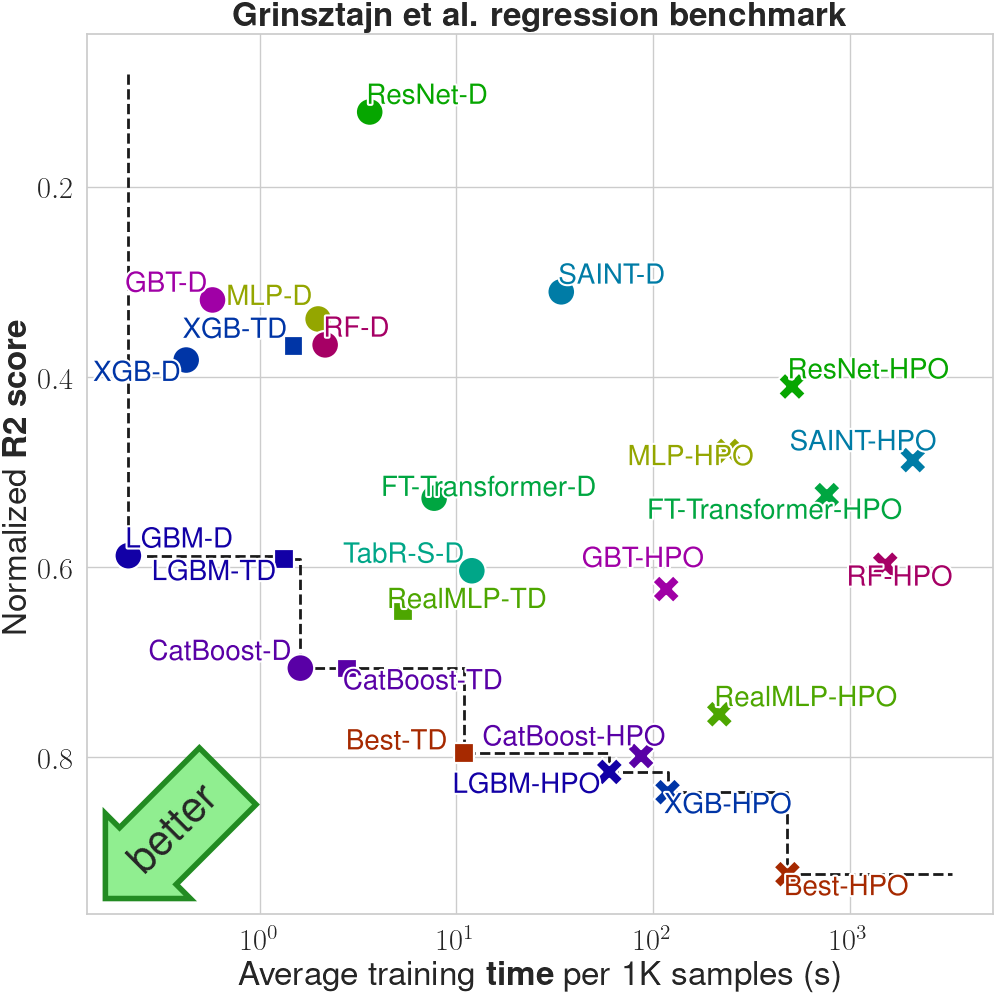

In [38]:
# import path effects
import matplotlib.patheffects as PathEffects    
# import adjustText, for repelling the labels
from adjustText import adjust_text

to_plot_reg = to_plot[to_plot["data__regression"] == True]
xlabel = r"Average training \textbf{time} per 1K samples (s)"
#ylabel = r"Normalized \textbf{R2 score}"
if metric == "normalize":
    ylabel = r"Normalized \textbf{R2 score}"
elif metric == "rank":
    ylabel = r"Arithmetic mean of \textbf{rank}"
elif metric == "nothing":
    ylabel = r"Mean \textbf{R2 score}"
title = "Grinsztajn et al. regression benchmark"
title = r'\textbf{' + title + r'}'

with plt.rc_context(figsizes.icml2022_half(height_to_width_ratio=2)):

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    # Create the scatter plot
    unique_algorithms = to_plot_reg['model_name'].unique()
    palette = {alg: get_plot_color(alg) for alg in unique_algorithms}
    
    ax = sns.scatterplot(
        x="x_value",
        y="y_value",
        hue="model_name",
        style="model_type",
        data=to_plot_reg,
        s=400,  # size of the points
        palette=palette,  # palette can be changed as needed
        legend=False,  # No need to draw legend at this point
        ax=ax,
    )

    ax.set_xscale('log')
    # ax.set_yscale('log')

    # Get the color of each point to set the color of the text
    point_colors = ax.collections[0].get_facecolor()

    # if y_intervals is not None:
    #     y_intervals_arr = np.array([y_intervals[model] for model in models])
    #     y_errors_arr = np.stack([np.array(y_vals) - y_intervals_arr[:, 0],
    #                              y_intervals_arr[:, 1] - np.array(y_vals)], axis=1)
    #     for x, y, errors, color in zip(x_vals, y_vals, y_errors_arr, point_colors):
    #         ax.errorbar(x, y, yerr=errors[:, None], fmt='none', color=color)

    # Prepare to annotate the points
    texts = []
    for i, point in enumerate(ax.collections[0].get_offsets()):
        model_name = to_plot_reg.iloc[i]['model']
        x, y = point
        text_color = point_colors[i]
        # Annotate the model names
        text = ax.text(x, y, model_name, color=text_color, fontsize=20, ha='center', va='center')
        text.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])
        texts.append(text)

    # Use adjust_text to repel the labels
    # Use adjust_text to repel the labels from each other and the points
    adjust_text(texts,
                x=to_plot_reg['x_value'].values,
                y=to_plot_reg['y_value'].values,
                avoid_self=False,
                expand=(1.15, 1.3),
                ax=ax,
                )

    # reverse y axis
    if metric == "normalize":
        plt.gca().invert_yaxis()

    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    eps = 0.1
    text_x = x_min ** (1 - eps) * x_max ** eps
    #text_x = x_max ** (1 - eps) * x_min ** eps
    text_y = y_min + eps * (y_max - y_min)
    #text_y = y_max + eps * (y_min - y_max)
    #text_y = 1 -  y_min + eps * (y_max - y_min)

    ax.set_axisbelow(True)

    # scatter.annotate('lower is better', xy=(text_x, text_y), rotation=)
    # ax.text(text_x, text_y, "lower is better",
    #         ha="center", va="center", rotation=-45, size=30)
    ax.text(text_x, text_y, "better",
            ha="center", va="center", rotation=45, size=30,
            bbox=dict(boxstyle="larrow,pad=0.5",
                        fc="lightgreen", ec="forestgreen", lw=4), zorder=1)

    # Set arrow coordinates based on the plot limits
    # arrow_x = x_min ** 0.1 * x_max ** 0.9  # Adjust 0.1 as needed
    # arrow_y = y_min + 0.1 * (y_max - y_min)  # Adjust 0.1 as needed
    #
    # # Set the corrected arrow properties
    # arrow_props = dict(facecolor='red', edgecolor='red', shrink=0.05, width=2, headwidth=10)
    #
    # # Add the arrow to the plot
    # ax.annotate('', xy=(arrow_x, arrow_y), xytext=(x_min, y_min),
    #                  arrowprops=arrow_props, annotation_clip=False)

#if plot_pareto_frontier:
    x_vals = to_plot_reg["x_value"]
    y_vals = to_plot_reg["y_value"]
    xs = np.array(x_vals)
    ys = np.array(y_vals)
    perm = np.argsort(xs)
    xs = xs[perm]
    ys = ys[perm]

    xs_pareto = [xs[0], xs[0]]
    ys_pareto = [ax.get_ylim()[1], ys[0]]
    for i in range(1, len(xs)):
        if ys[i] > ys_pareto[-1] if metric == "normalize" else ys[i] < ys_pareto[-1]:
            xs_pareto.append(xs[i])
            ys_pareto.append(ys_pareto[-1])
            xs_pareto.append(xs[i])
            ys_pareto.append(ys[i])
    xs_pareto.append(ax.get_xlim()[1])
    ys_pareto.append(ys_pareto[-1])

    ax.plot(xs_pareto, ys_pareto, '--', color='k', linewidth=2, zorder=0.8)

    # Set the axis labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)

    

    plt.savefig(f"../analyses/plots/grinsztajn_regression_{metric}.pdf", bbox_inches='tight')


In [39]:
to_plot_classif = to_plot[to_plot["data__regression"] == False]
xlabel = r"Average training \textbf{time} per 1K samples (s)"
if metric == "normalize":
    ylabel = r"Normalized \textbf{accuracy}"
elif metric == "rank":
    ylabel = r"Arithmetic mean of \textbf{rank}"
elif metric == "nothing":
    ylabel = r"Mean \textbf{accuracy}"
#ylabel = r"Arithmetic mean of \textbf{rank}"
title = "Grinsztajn et al. classification benchmark"
title = r'\textbf{' + title + r'}'

# import path effects
import matplotlib.patheffects as PathEffects    
# import adjustText, for repelling the labels
from adjustText import adjust_text

with plt.rc_context(figsizes.icml2022_half(height_to_width_ratio=1)):

    fig, ax = plt.subplots(1, 1, figsize=(10, 10))
    # Create the scatter plot
    unique_algorithms = to_plot_classif['model_name'].unique()
    palette = {alg: get_plot_color(alg) for alg in unique_algorithms}
    
    ax = sns.scatterplot(
        x="x_value",
        y="y_value",
        hue="model_name",
        style="model_type",
        data=to_plot_classif,
        s=400,  # size of the points
        palette=palette,  # palette can be changed as needed
        legend=False,  # No need to draw legend at this point
        ax=ax,
    )

    ax.set_xscale('log')
    # ax.set_yscale('log')

    # Get the color of each point to set the color of the text
    point_colors = ax.collections[0].get_facecolor()

    # if y_intervals is not None:
    #     y_intervals_arr = np.array([y_intervals[model] for model in models])
    #     y_errors_arr = np.stack([np.array(y_vals) - y_intervals_arr[:, 0],
    #                              y_intervals_arr[:, 1] - np.array(y_vals)], axis=1)
    #     for x, y, errors, color in zip(x_vals, y_vals, y_errors_arr, point_colors):
    #         ax.errorbar(x, y, yerr=errors[:, None], fmt='none', color=color)

    # Prepare to annotate the points
    texts = []
    for i, point in enumerate(ax.collections[0].get_offsets()):
        model_name = to_plot_classif.iloc[i]['model']
        x, y = point
        text_color = point_colors[i]
        # Annotate the model names
        text = ax.text(x, y, model_name, color=text_color, fontsize=20, ha='center', va='center')
        text.set_path_effects([PathEffects.withStroke(linewidth=3, foreground='white')])
        texts.append(text)

    # Use adjust_text to repel the labels
    # Use adjust_text to repel the labels from each other and the points
    adjust_text(texts,
                x=to_plot_classif['x_value'].values,
                y=to_plot_classif['y_value'].values,
                avoid_self=False,
                expand=(1.15, 1.3),
                ax=ax,
                )

    # reverse y axis
    if metric == "normalize":
        plt.gca().invert_yaxis()

    
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()
    eps = 0.1
    text_x = x_min ** (1 - eps) * x_max ** eps
    #text_x = x_max ** (1 - eps) * x_min ** eps
    text_y = y_min + eps * (y_max - y_min)
    #text_y = y_max + eps * (y_min - y_max)
    #text_y = 1 -  y_min + eps * (y_max - y_min)

    ax.set_axisbelow(True)

    # scatter.annotate('lower is better', xy=(text_x, text_y), rotation=)
    # ax.text(text_x, text_y, "lower is better",
    #         ha="center", va="center", rotation=-45, size=30)
    ax.text(text_x, text_y, "better",
            ha="center", va="center", rotation=45, size=30,
            bbox=dict(boxstyle="larrow,pad=0.5",
                        fc="lightgreen", ec="forestgreen", lw=4), zorder=1)

    # Set arrow coordinates based on the plot limits
    # arrow_x = x_min ** 0.1 * x_max ** 0.9  # Adjust 0.1 as needed
    # arrow_y = y_min + 0.1 * (y_max - y_min)  # Adjust 0.1 as needed
    #
    # # Set the corrected arrow properties
    # arrow_props = dict(facecolor='red', edgecolor='red', shrink=0.05, width=2, headwidth=10)
    #
    # # Add the arrow to the plot
    # ax.annotate('', xy=(arrow_x, arrow_y), xytext=(x_min, y_min),
    #                  arrowprops=arrow_props, annotation_clip=False)

    #if plot_pareto_frontier:
    x_vals = to_plot_classif["x_value"]
    y_vals = to_plot_classif["y_value"]
    xs = np.array(x_vals)
    ys = np.array(y_vals)
    perm = np.argsort(xs)
    xs = xs[perm]
    ys = ys[perm]

    xs_pareto = [xs[0], xs[0]]
    ys_pareto = [ax.get_ylim()[1], ys[0]]
    for i in range(1, len(xs)):
        if ys[i] > ys_pareto[-1] if metric == "normalize" else ys[i] < ys_pareto[-1]:
            xs_pareto.append(xs[i])
            ys_pareto.append(ys_pareto[-1])
            xs_pareto.append(xs[i])
            ys_pareto.append(ys[i])
    xs_pareto.append(ax.get_xlim()[1])
    ys_pareto.append(ys_pareto[-1])

    ax.plot(xs_pareto, ys_pareto, '--', color='k', linewidth=2, zorder=0.8)

    # Set the axis labels
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    if title is not None:
        ax.set_title(title)

    #plt.savefig("../analyses/plots/grinsztajn_classif_rank_27_03.pdf", bbox_inches='tight')
    plt.savefig(f"../analyses/plots/grinsztajn_classif_{metric}.pdf", bbox_inches='tight')
    #plt.plot()


/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:1498: FutureWarning:

is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, CategoricalDtype) instead

/Users/leo/mambaforge/envs/skrub/lib/python3.10/site-packages/seaborn/_oldcore.py:14